In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_sales_data.csv to ecommerce_sales_data (1).csv


In [16]:
import pandas as pd
df = pd.read_csv("ecommerce_sales_data.csv")

In [17]:
df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3511 entries, 0 to 3510
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order Date     3499 non-null   object 
 1   Product Name   3499 non-null   object 
 2   Category       3499 non-null   object 
 3   Region         3499 non-null   object 
 4   Quantity       3501 non-null   object 
 5   Sales          3507 non-null   object 
 6   Profit         3501 non-null   object 
 7   Year           3499 non-null   float64
 8   Month          3499 non-null   object 
 9   Quarter        3499 non-null   object 
 10  profit margin  3499 non-null   float64
dtypes: float64(2), object(9)
memory usage: 301.9+ KB


,Year,profit margin
count,3499.000000,3499.000000
mean,2027.202344,0.173721
std,2.781686,0.071017
min,2022.000000,0.050047
25%,2025.000000,0.113808
50%,2027.000000,0.172308
75%,2030.000000,0.233451
max,2032.000000,0.299951


In [18]:
df.isnull().sum()

,0
Order Date,12
Product Name,12
Category,12
Region,12
Quantity,10
Sales,4
Profit,10
Year,12
Month,12
Quarter,12


In [19]:
df.duplicated().sum()

np.int64(3)

In [20]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [22]:
df["Sales"].dtype

dtype('O')

In [23]:
df["Sales"].head(10)

,Sales
0,1197
1,5865
2,786
3,509
4,524
5,6167
6,3059
7,5526
8,672
9,7074


In [24]:
df["Sales"] = df["Sales"].astype(str).str.replace(",", "")

In [25]:
df["Sales"].sum()

'119758657865095246167305955266727074502746242055704417469221274066257122739140034773475613836652372138211261376988107733252273927099363720532080412248667301843251557367233323848883280123958801668410959581551872212452105761689521188308514730546057952008284234041065214959123348240932862242530410816401114453600133530903910219390329445729802262751887315127053256556710188025592185219578844360492034749301421634673313588211923908346128073264032344435230217282283450745647289452966407971456403856563876100221877146189940951124750681762125967270100356792714765422121081053033961060480252947928056422865374524128509049302610213922622443150338887361102264025477283444314043585611222471512491527091239572170836038224680252021382529236273030212447284533792130412031502688175273082007722469395516222439852723746317055048032841748824187262756612910903648151187333962020253030655223833129387579027002072299155685509592243801760557110825693416570330025847650360084651705638429281904231410288307153925065778101889

In [26]:
print(df["Sales"].dtype)

print(df["Sales"].head(10))

print(df["Sales"].unique()[:20])

object
0    1197
1    5865
2     786
3     509
4     524
5    6167
6    3059
7    5526
8     672
9    7074
Name: Sales, dtype: object
['1197' '5865' '786' '509' '524' '6167' '3059' '5526' '672' '7074' '502'
 '7462' '4205' '570' '441' '7469' '2212' '740' '662' '5712']


In [27]:
df["Profit"].head(10)

,Profit
0,106.53
1,502.73
2,202.87
3,103.28
4,106.35
5,1027.98
6,873.5
7,595.28
8,186.37
9,1357.68


In [28]:
df["Profit"] = df["Profit"].astype(str).str.replace(",", "")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

In [29]:
df["Profit"].sum()

np.float64(3688632.56)

In [30]:
df.groupby("Category")["Sales"].sum()

,Sales
Category,
Accessories,1197786509616770744417469662571214009883252273...
Electronics,5865524305955265027462420557022127402739347561...
Office,6723477237213769364109164036003910390124679271...


In [31]:
df.groupby("Category")["Profit"].sum()

,Profit
Category,
Accessories,736084.74
Electronics,923185.59
Office,185045.95


In [32]:
df.groupby("Region")["Sales"].sum()

,Sales
Region,
East,1197552650244174080458808155212421184730579534...
North,6167746274696625712273934773475237213821077327...
South,5865786305967270742212325227098667155736721239...
West,5095244205570140061383665112613769889363720532...


In [33]:
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

,Sales
Product Name,
Monitor,7074301836721872521098019544351456403894081761...
Printer,6723477237213769364109164036003910390124679271...
Headphones,6167441662325227398048667238458808155689557954...
Laptop,6138138211261077312244325155732802008111329470...
Tablet,5865746222127402709473021493285561852142183434...
Smartwatch,5526502273959521242118830851106525303256230294...
Camera,5243059570347536653720219751887367317284930344...
Smartphone,4205166824096224390882119261232347456472864021...
Keyboard,1400591230904572930264010021891003533968561512...


In [34]:
monthly=df.groupby("Month")["Sales"].sum()
monthly

,Sales
Month,
April,4728945296640797145640385656387610022187714618...
August,5693416570330025847650360084651705638429281904...
December,5246167305955266727074502746242055704417469221...
February,2008284234041065214959123348240932862242530410...
January,9363720532080412248667301843251557367233323848...
July,5504803284174882418726275661291090364815118733...
June,5721708360382246802520213825292362730302124472...
March,7053256556710188025592185219578844360492034749...
May,4802529479280564228653745241285090493026102139...


In [35]:
print(df["Sales"].dtype)

object


In [36]:
df["Sales"].head(10)

,Sales
0,1197
1,5865
2,786
3,509
4,524
5,6167
6,3059
7,5526
8,672
9,7074


In [37]:
df["Sales"] = df["Sales"].astype(str).str.replace(",", "", regex=False)
df["Sales"] = df["Sales"].str.replace("₹", "", regex=False)
df["Sales"] = df["Sales"].str.replace("$", "", regex=False)
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

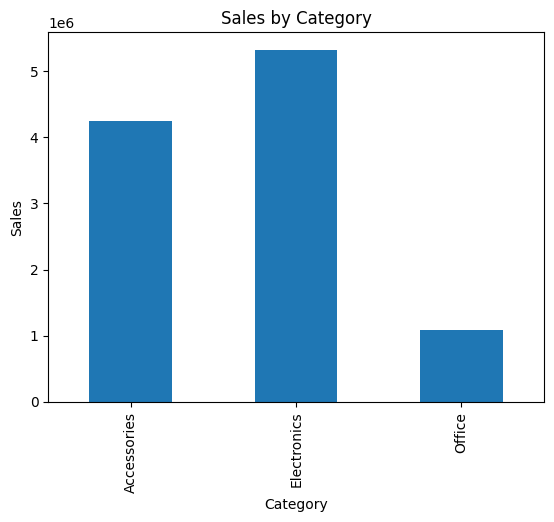

In [38]:
import matplotlib.pyplot as plt

df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

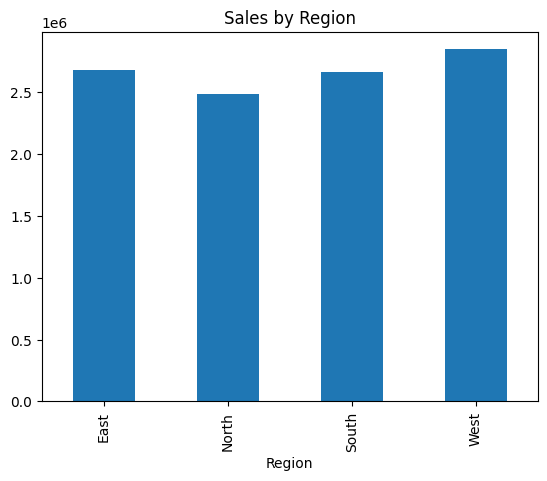

In [39]:
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.show()

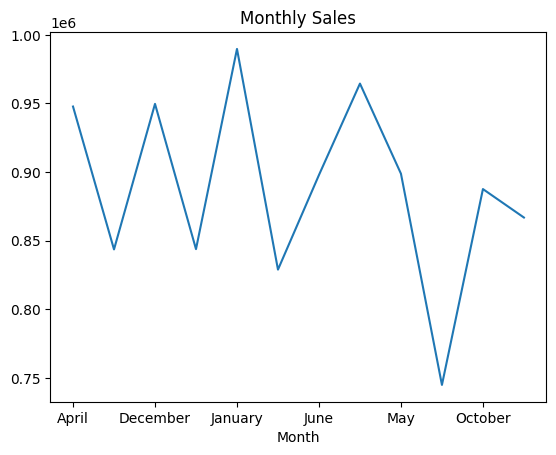

In [40]:
df.groupby("Month")["Sales"].sum().plot(kind="line")
plt.title("Monthly Sales")
plt.show()

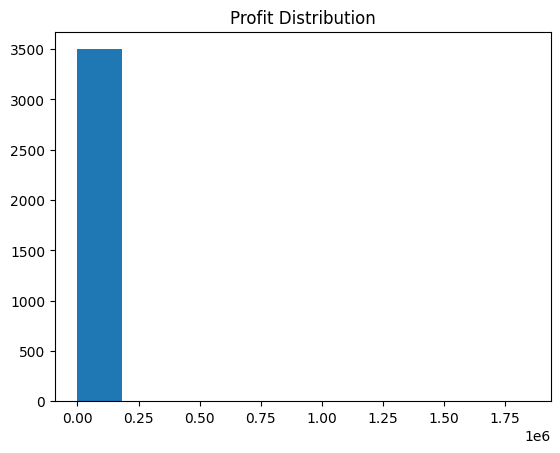

In [41]:
plt.hist(df["Profit"])
plt.title("Profit Distribution")
plt.show()

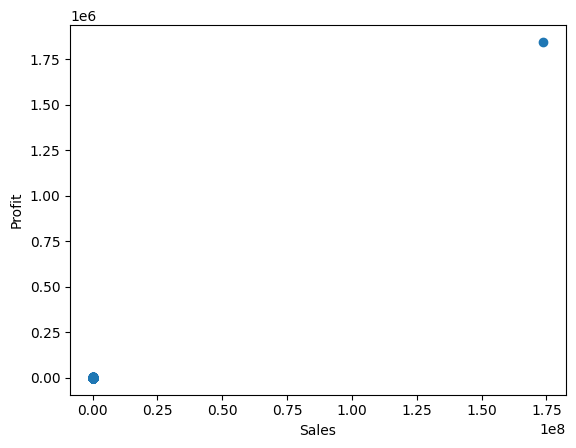

In [42]:
plt.scatter(df["Sales"],df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

In [43]:
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

In [44]:
category_profit = df.groupby("Category")["Profit"].sum()

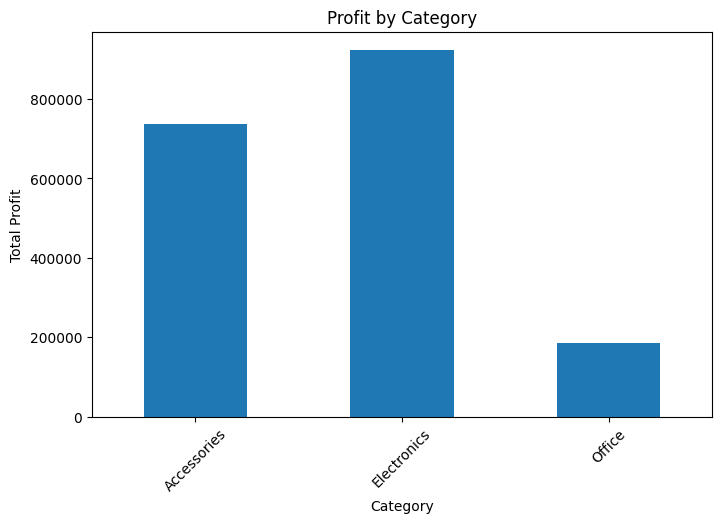

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.show()

In [46]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")  # Professional style
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13

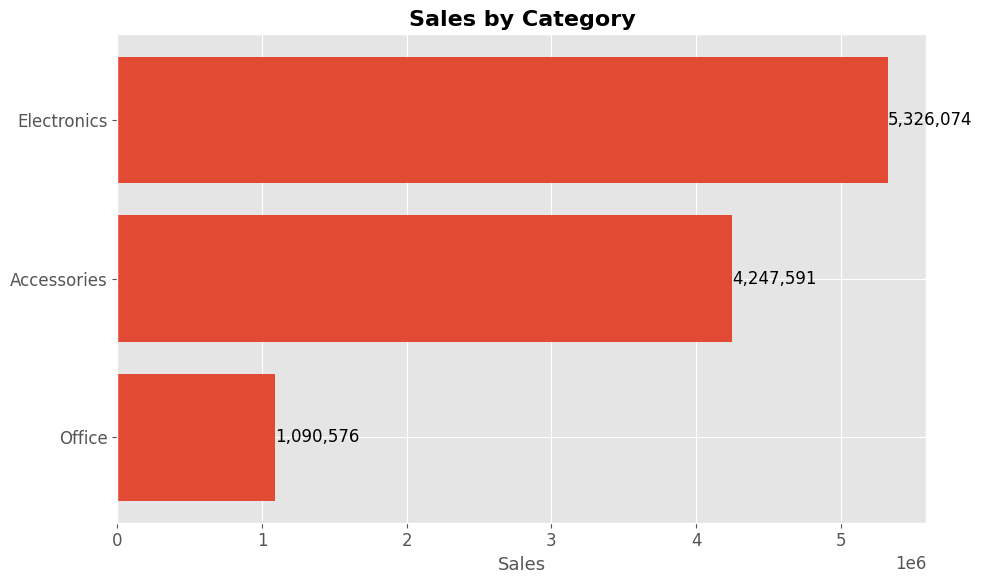

In [47]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(category_sales.index, category_sales.values)

plt.title("Sales by Category", fontweight="bold")
plt.xlabel("Sales")

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}",
             va="center")

plt.tight_layout()
plt.show()

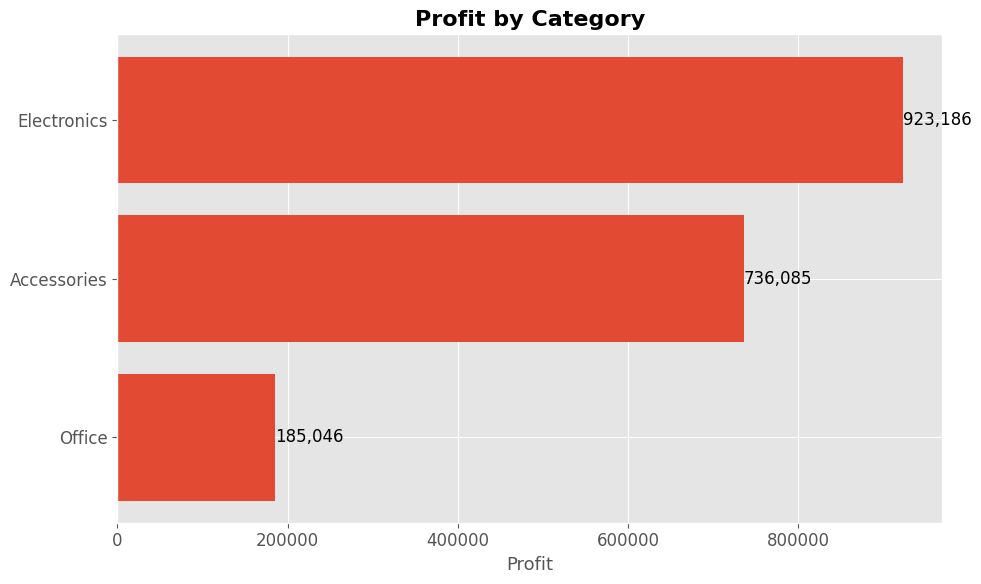

In [48]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values()

plt.figure(figsize=(10,6))

bars = plt.barh(category_profit.index,
                category_profit.values)

plt.title("Profit by Category", fontweight="bold")
plt.xlabel("Profit")

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}",
             va="center")

plt.tight_layout()
plt.show()

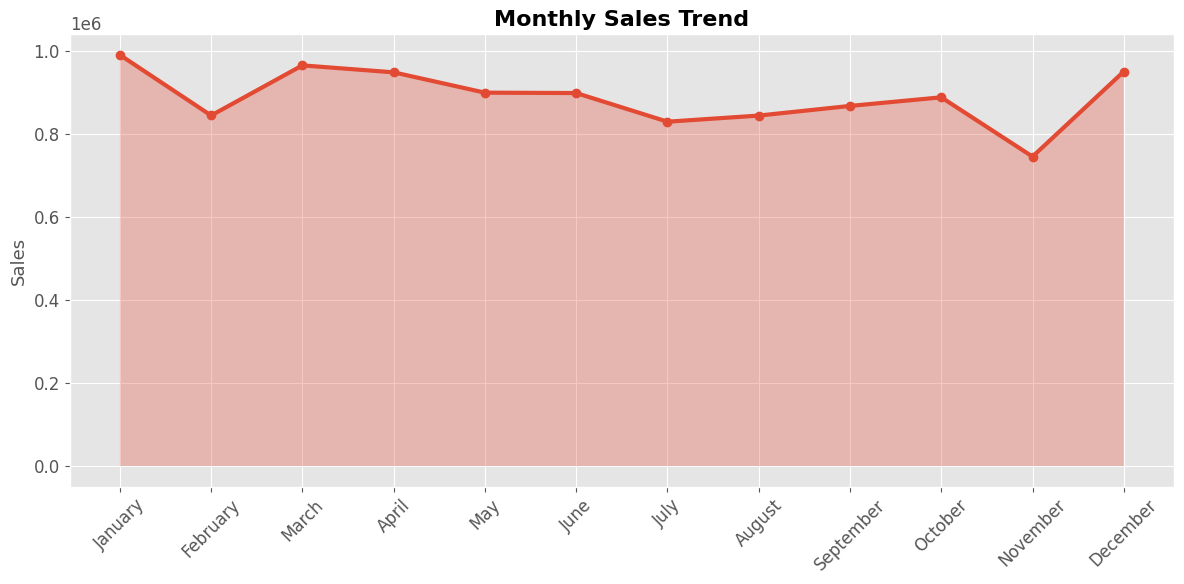

In [49]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         linewidth=3,
         marker="o")

plt.fill_between(monthly_sales.index,
                 monthly_sales.values,
                 alpha=0.3)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend", fontweight="bold")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

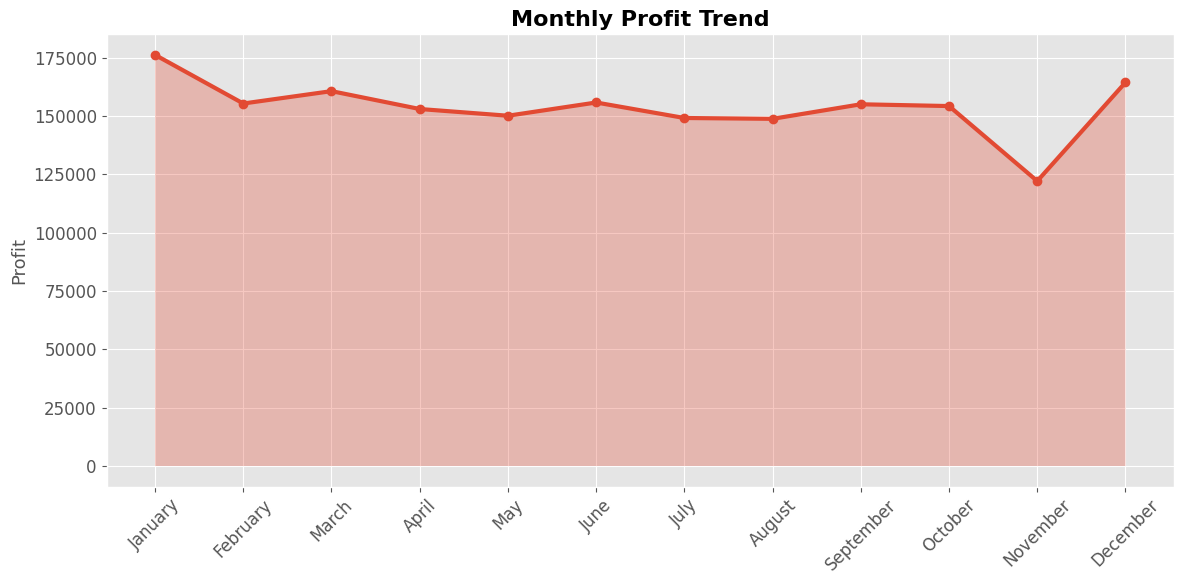

In [50]:
monthly_profit = (
    df.groupby("Month")["Profit"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(12,6))

plt.plot(monthly_profit.index,
         monthly_profit.values,
         linewidth=3,
         marker="o")

plt.fill_between(monthly_profit.index,
                 monthly_profit.values,
                 alpha=0.3)

plt.xticks(rotation=45)

plt.title("Monthly Profit Trend", fontweight="bold")

plt.ylabel("Profit")

plt.tight_layout()

plt.show()

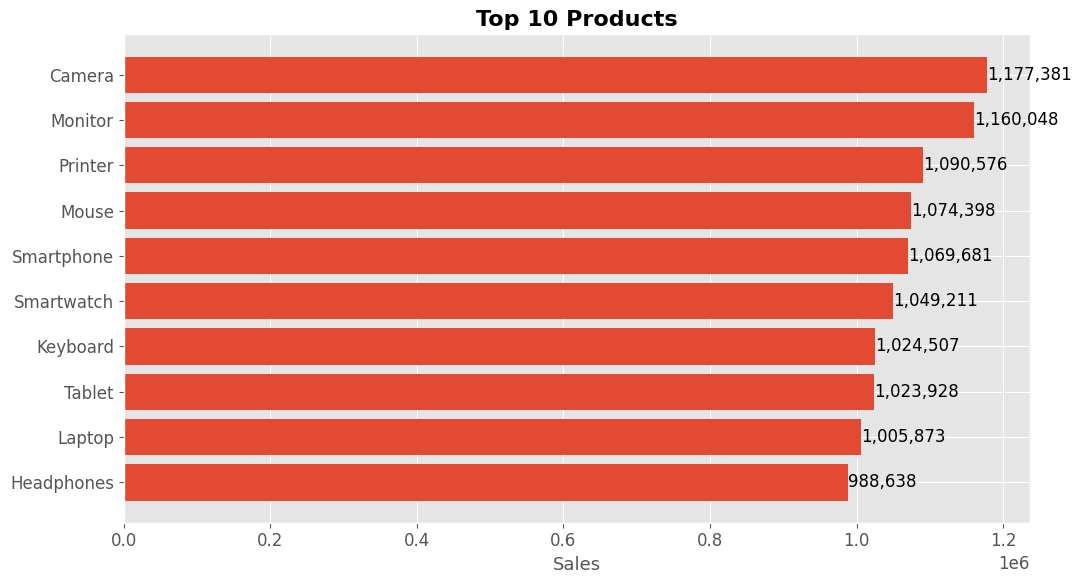

In [51]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(11,6))

bars = plt.barh(top_products.index,
                top_products.values)

plt.title("Top 10 Products", fontweight="bold")

plt.xlabel("Sales")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(bar.get_width(),
             bar.get_y()+bar.get_height()/2,
             f"{bar.get_width():,.0f}",
             va="center")

plt.tight_layout()

plt.show()

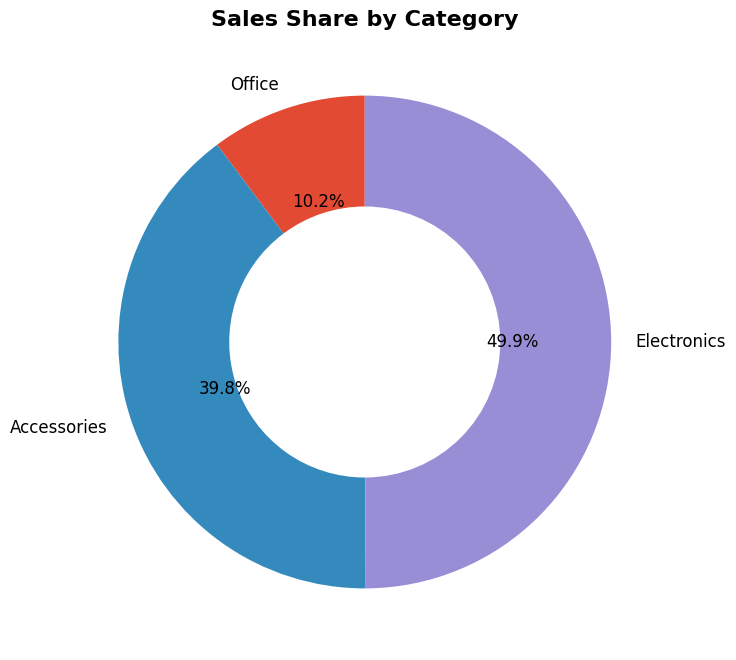

In [52]:
plt.figure(figsize=(8,8))

plt.pie(category_sales,
        labels=category_sales.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(width=0.45))

plt.title("Sales Share by Category", fontweight="bold")

plt.show()

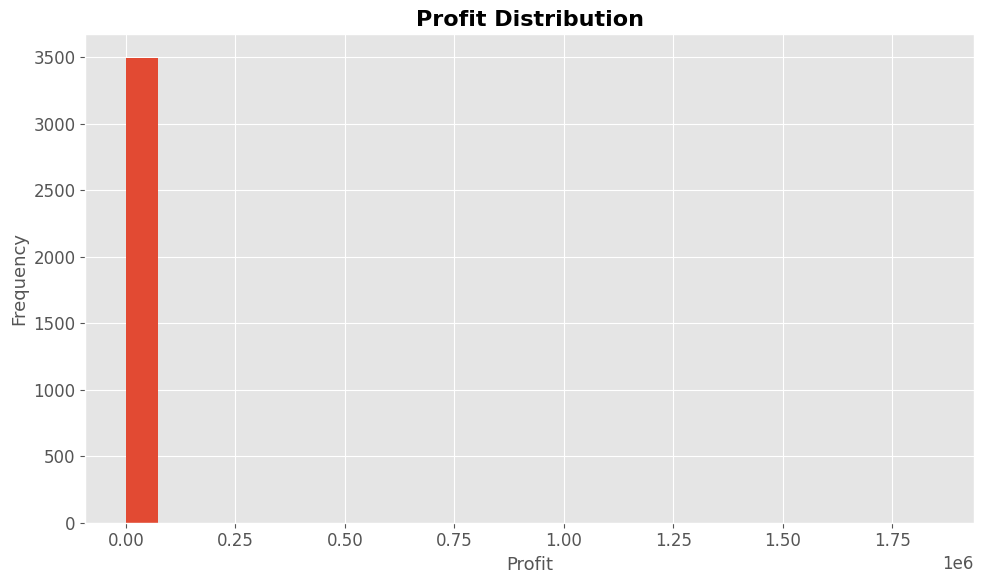

In [53]:
plt.figure(figsize=(10,6))

plt.hist(df["Profit"],
         bins=25)

plt.title("Profit Distribution", fontweight="bold")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

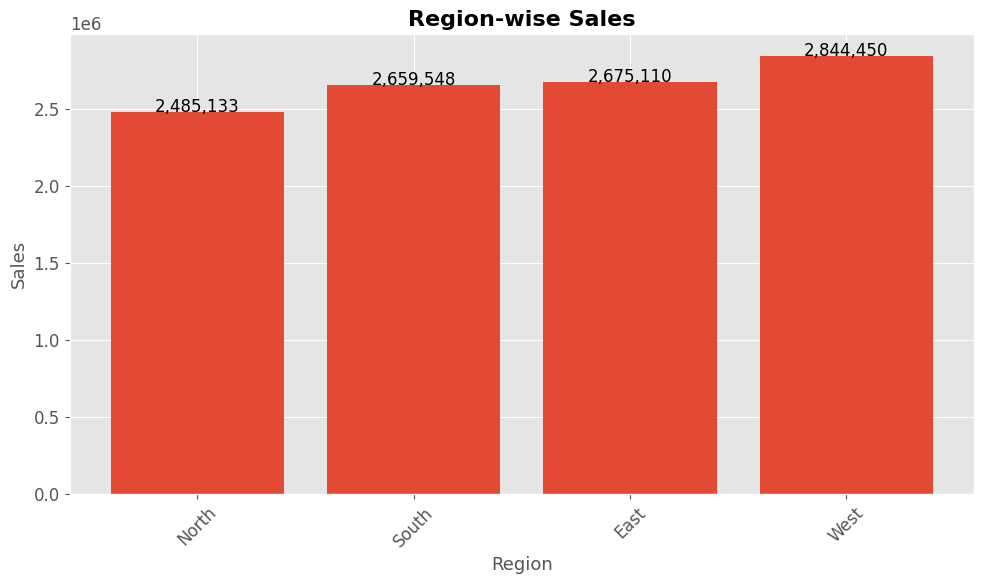

In [54]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(10,6))

bars = plt.bar(region_sales.index,
               region_sales.values)

plt.title("Region-wise Sales", fontweight="bold")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():,.0f}",
             ha="center")

plt.tight_layout()

plt.show()

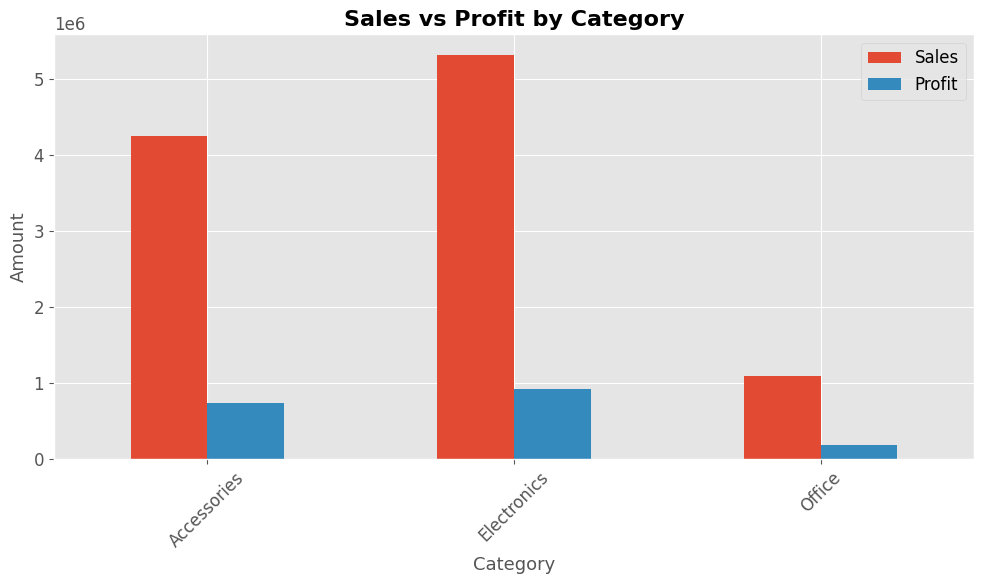

In [55]:
comparison = df.groupby("Category")[["Sales","Profit"]].sum()

comparison.plot(kind="bar",
                figsize=(10,6))

plt.title("Sales vs Profit by Category", fontweight="bold")

plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

In [57]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

In [58]:
correlation = df[["Sales", "Profit", "Quantity"]].corr()

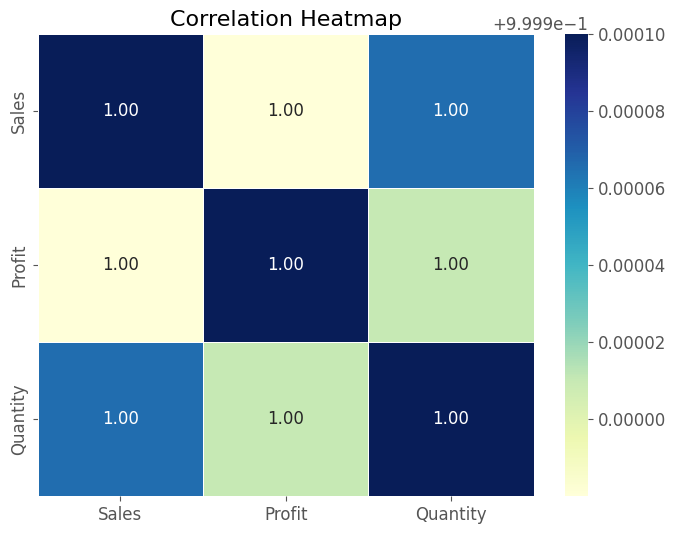

In [59]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()